In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install "zarr>=2.16.0,<3.0.0" numcodecs umap-learn

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 24.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 154.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 53.1 MB/s eta 0:00:00
  Created wheel for asciitree: filename=asciitree-0.3.3-py3-none-any.whl size=5031 sha256=fc2ea21f67a7b4fb1f88f49df731483906754f40bd45fa856628b004f16d6d20
  Stored in directory: /root/.cache/pip/wheels/a5/d7/98/f56ae733748cd0fa577172bda0e73e0b1f1793c98e09b9e458
Successfully built asciitree


In [3]:
import os
import shutil
import datetime
import gc
import numpy as np
import tensorflow as tf
import random
from typing import Literal
import matplotlib.pyplot as plt
import pandas as pd
import math
from dataclasses import dataclass
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [4]:
ModelType = Literal["pair", "triplet"]

@dataclass
class ModelConfig:
    type: ModelType

@dataclass
class DataConfig:
    authors: int
    authors_range: range
    original_shape: tuple[int, int, int]
    model_input_shape: tuple[int, int, int]

    def __post_init__(self):
        # Validate authors
        assert self.authors > 0, "authors must be positive"

        # Validate range consistency
        assert isinstance(self.authors_range, range), "authors_range must be a range"

        expected_len = self.authors_range.stop - self.authors_range.start
        assert expected_len == self.authors, (
            f"authors ({self.authors}) != range size ({expected_len})"
        )

        # Validate shapes
        assert self.original_shape[-1] in (1, 3), "invalid original channels"
        assert self.model_input_shape[-1] in (1, 3), "invalid input channels"


@dataclass
class TrainingConfig:
    epochs: int
    seed: int
    val_ratio: float

    def __post_init__(self):
        assert 0 < self.val_ratio < 1, "val_ratio must be between 0 and 1"


@dataclass
class BatchConfig:
    train: int
    validation: int
    test: int

    def __post_init__(self):
        assert self.train > 0
        assert self.validation > 0
        assert self.test > 0


@dataclass
class Config:
    project_path: str
    dataset: str
    model: ModelConfig
    data: DataConfig
    training: TrainingConfig
    batch: BatchConfig
    current_time: str

In [5]:
config = Config(
    project_path='drive/MyDrive/author-handwriting-recog',
    dataset='dataset_4_ImagesLinesRemoved_20260310-153450',
    model=ModelConfig(type="triplet"),
    data=DataConfig(
        authors=40,
        authors_range=range(0, 40),
        original_shape=(180, 360, 1),
        model_input_shape=(120, 240, 3),
    ),
    training=TrainingConfig(
        epochs=30,
        seed=42,
        val_ratio=0.25
    ),
    batch=BatchConfig(
        train=16,
        validation=8,
        test=4,
    ),
    current_time=datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
)

In [6]:
def upload_source(source: str, source_dest: str):
    if os.path.exists(source_dest):
        shutil.rmtree(source_dest)

    shutil.copytree(source, source_dest)

In [7]:
src_drive = f"{config.project_path}/src"
src_local = "./src"

In [8]:
src_data_drive = f"{config.project_path}/data/datasets/180_360_90"
src_data_local = f"./dataset"

In [9]:
upload_source(source=src_drive, source_dest=src_local)

In [10]:
upload_source(source=src_data_drive, source_dest=src_data_local)

In [11]:
random.seed(config.training.seed)
np.random.seed(config.training.seed)
tf.random.set_seed(config.training.seed)

In [12]:
from src.io import LoggerFactory
from src.datasets.loaders import SelectiveDataLoader
from src.generators import (
    AugmentationPipeline,
    AugmentationOps,
    AugmentImage,
    BaseGenerator,
    DataGenerator,
    TripletGenerator,
)

In [13]:
from src.models import MobileNetV2Backbone, TripletLoss
from src.training import (
    get_default_callbacks,
    ModelTrainerFactory,
)
from src.evaluator import (
    TripletEvaluator,
)

In [ ]:
from src.evaluator.embedding_utils import EmbeddingExtractor
from src.evaluator.embedding_strategy import (
    StrategyPipeline,
    OneNNStrategy,
    MeanStrategy,
    CentroidStrategy,
    TopKStrategy,
    PatchAggregator,
    VoteAggregator,
    ScoreAggregator,
)
from src.evaluator import EmbeddingEvaluator, EmbeddingVisualizer

In [14]:
logger = LoggerFactory.get_logger(
    "mobile_test_40_4",
    log_dir=f"./logs_{config.current_time}",
    file_prefix=f"mobile_triplet_{config.current_time}"
)

In [15]:
dataset_path = f"dataset/{config.dataset}.tar.gz"

In [16]:
!tar -xzf {dataset_path} -C ./

In [17]:
loader = SelectiveDataLoader(
    dataset_path=f"./{config.dataset}.zarr",
    seed=config.training.seed
)

In [18]:
train, val, test = loader.build(
      author_range=config.data.authors_range,
      validation_fraction=config.training.val_ratio,
  )

12:10:03 - src.datasets.loaders.selective_data_loader - INFO - Total patches selected: 25147
12:10:03 - src.datasets.loaders.selective_data_loader - INFO - Train: 18860 | Val: 6287 | Test: 1733
12:10:03 - src.datasets.loaders.selective_data_loader - INFO - Avg non_test patches per author: 628.67 | Min: 399 | Max: 808
12:10:03 - src.datasets.loaders.selective_data_loader - INFO - Avg test patches per author: 43.33 | Min: 34 | Max: 48
12:10:03 - src.datasets.loaders.selective_data_loader - INFO - Image shape: (180, 360)
12:10:03 - src.datasets.loaders.selective_data_loader - INFO - Zarr chunk shape: (64, 180, 360)


In [19]:
ops = AugmentationOps(
    rotation_range=6,
    width_shift_range=0.04,
    height_shift_range=0.05,
    horizontal_flip=False,
    resize_dim=config.data.model_input_shape[:2],
    brightness_delta=0.04,
    contrast_range=(0.95, 1.05),
    noise_stddev=0.01,
    zoom_range=(0.95, 1.05),
)
pipeline_train = AugmentationPipeline([
    ops.rotate,
    ops.zoom,
    ops.shift,
    ops.resize,
    ops.to_rgb,
    ops.clip_255,
    ops.mobilenet_preprocess,
])
pipeline = AugmentationPipeline([
    ops.resize,
    ops.to_rgb,
    ops.clip_255,
    ops.mobilenet_preprocess,
])
augment_train = AugmentImage(pipeline_train)
augment = AugmentImage(pipeline)

In [20]:
train_triplet = TripletGenerator(
    cache=train.cache,
    labels=train.labels,
    indices=train.indices,
    batch_size=config.batch.train,
    seed=config.training.seed,
    augment=augment_train
)
val_triplet = TripletGenerator(
    cache=val.cache,
    labels=val.labels,
    indices=val.indices,
    batch_size=config.batch.validation,
    seed=config.training.seed,
    augment=augment
)
test_triplet = TripletGenerator(
    cache=test.cache,
    labels=test.labels,
    indices=test.indices,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [21]:
def display_generator_info(generator: BaseGenerator):
    config = generator.get_config()
    logger.info(f"Generator: {generator.__class__.__name__}")
    logger.info(f"Number of samples: {config['num_samples']}")
    logger.info(f"Batch size: {config['batch_size']}")
    logger.info(f"Steps per epoch: {config['steps_per_epoch']}")
    logger.info(f"Shape: {config['patch_shape']}")
    logger.info(f"Number of authors: {config['num_authors']}")

In [22]:
display_generator_info(train_triplet)

12:10:04 - mobile_test_40_4 - INFO - Generator: TripletGenerator
12:10:04 - mobile_test_40_4 - INFO - Number of samples: 18860
12:10:04 - mobile_test_40_4 - INFO - Batch size: 16
12:10:04 - mobile_test_40_4 - INFO - Steps per epoch: 1179
12:10:04 - mobile_test_40_4 - INFO - Shape: (180, 360)
12:10:04 - mobile_test_40_4 - INFO - Number of authors: 40


In [23]:
display_generator_info(val_triplet)

12:10:04 - mobile_test_40_4 - INFO - Generator: TripletGenerator
12:10:04 - mobile_test_40_4 - INFO - Number of samples: 6287
12:10:04 - mobile_test_40_4 - INFO - Batch size: 8
12:10:04 - mobile_test_40_4 - INFO - Steps per epoch: 786
12:10:04 - mobile_test_40_4 - INFO - Shape: (180, 360)
12:10:04 - mobile_test_40_4 - INFO - Number of authors: 40


In [24]:
display_generator_info(test_triplet)

12:10:04 - mobile_test_40_4 - INFO - Generator: TripletGenerator
12:10:04 - mobile_test_40_4 - INFO - Number of samples: 1733
12:10:04 - mobile_test_40_4 - INFO - Batch size: 4
12:10:04 - mobile_test_40_4 - INFO - Steps per epoch: 434
12:10:04 - mobile_test_40_4 - INFO - Shape: (180, 360)
12:10:04 - mobile_test_40_4 - INFO - Number of authors: 40


In [25]:
trainer = ModelTrainerFactory.create(
    backbone=MobileNetV2Backbone(freeze_base=False, fine_tune_at=100),
    input_shape=config.data.model_input_shape,
    num_authors=config.data.authors,
    train_generator=train_triplet,
    val_generator=val_triplet,
    model_name="mobilenet_triplet",
    model_type=config.model.type,
)

12:10:14 - src.training.base_metric_trainer - INFO - [EmbeddingConfig] author=40 | embedding_dim=160 | projection_dim=320


In [26]:
trainer.initialize_model()

/content/src/models/backbones/mobile_net.py:13: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


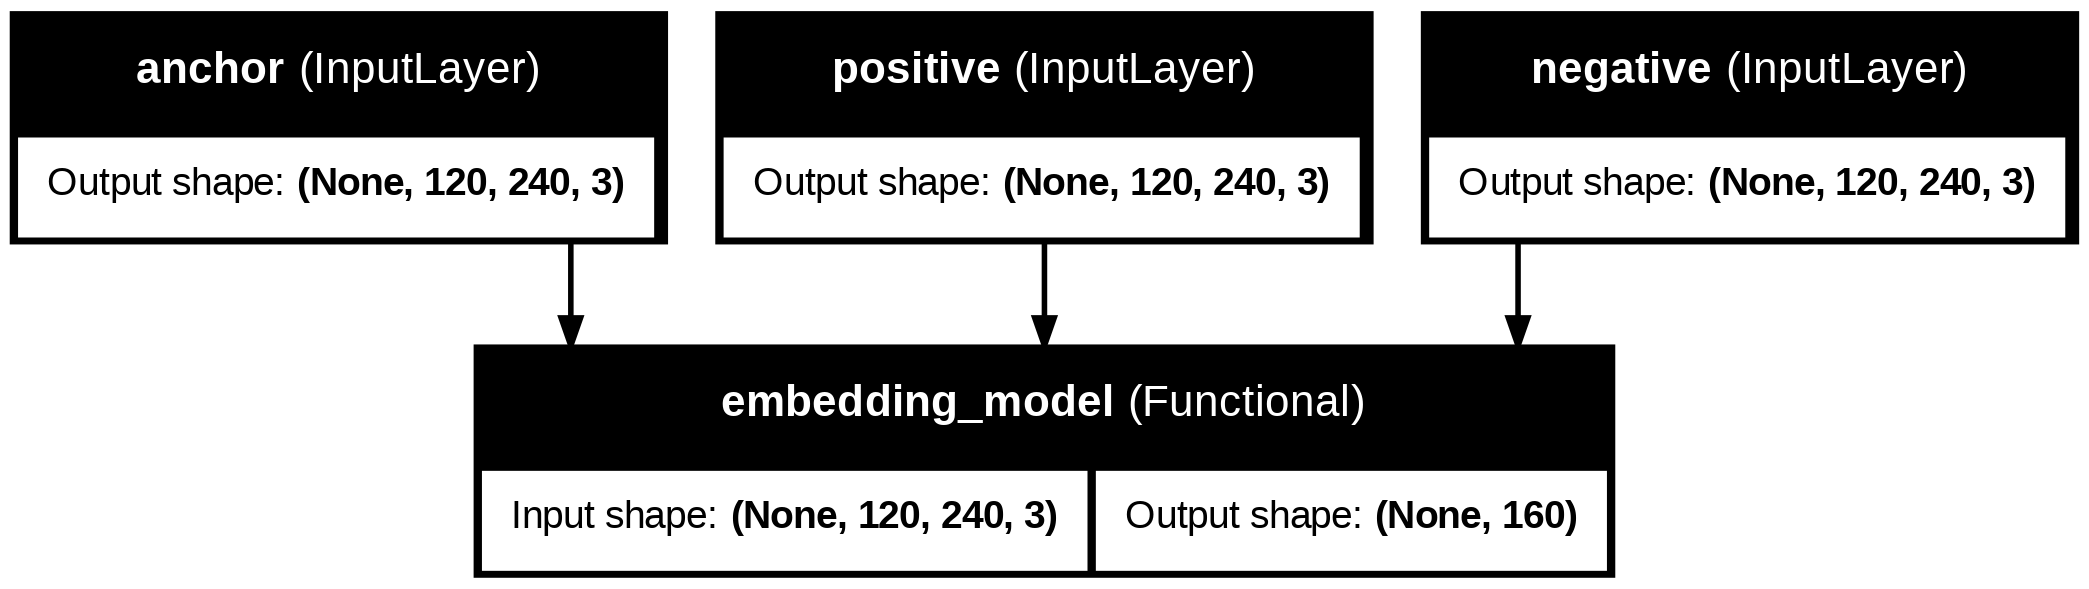

In [27]:
tf.keras.utils.plot_model(
    trainer.siamese_network,
    show_shapes=True,
    show_layer_names=True,
)

In [28]:
trainer.siamese_network.summary()

Model: "siamese_triplet_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor (InputLayer) │ (None, 120, 240,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive            │ (None, 120, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative            │ (None, 120, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_model     │ (None, 160)       │  2,721,184 │ anchor[0][0],     │
│ (Functional)        │                   │            │ positive[0][0],   │
│                     │                   │            │ negative[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,721,184 (10.38 MB)

 Trainable params: 2,323,680 (8.86 MB)

 Non-trainable params: 397,504 (1.52 MB)

In [29]:
trainer.embedding_model.summary()

Model: "embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 240, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 4, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ projection_dense_1 (Dense)      │ (None, 320)            │       409,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 320)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 320)            │         1,280 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_projection (Dense)    │ (None, 160)            │        51,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 160)            │           640 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalization                │ (None, 160)            │             0 │
│ (L2Normalization)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,721,184 (10.38 MB)

 Trainable params: 2,323,680 (8.86 MB)

 Non-trainable params: 397,504 (1.52 MB)

In [30]:
trainer.compile(
    loss=TripletLoss(margin=0.4),
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics=[
        tf.keras.metrics.Mean(name="ap_sim"),
        tf.keras.metrics.Mean(name="an_sim"),
        tf.keras.metrics.Mean(name="margin"),
        tf.keras.metrics.Mean(name="triplet_acc"),
    ],
)

In [32]:
callbacks = get_default_callbacks(
    model_name="mobile_siamese_triplet",
    monitor="val_loss",
    mode="min",
    patience=4,
    start_from_epoch=5,
    reduce_lr_patience=2,
)

In [33]:
history = trainer.train_model(
    epochs=config.training.epochs,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step - an_sim: -0.0014 - ap_sim: 0.0367 - loss: 0.3628 - margin: 0.0381 - triplet_acc: 0.5962
Epoch 1: val_loss improved from None to 0.32243, saving model to checkpoints/mobile_siamese_triplet/best.keras

Epoch 1: finished saving model to checkpoints/mobile_siamese_triplet/best.keras
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 222s 139ms/step - an_sim: 9.3276e-04 - ap_sim: 0.0572 - loss: 0.3466 - margin: 0.0562 - triplet_acc: 0.6208 - val_an_sim: 0.0734 - val_ap_sim: 0.1566 - val_loss: 0.3224 - val_margin: 0.0832 - val_triplet_acc: 0.6622 - learning_rate: 1.0000e-05
Epoch 2/30
1177/1179 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - an_sim: 1.5654e-04 - ap_sim: 0.1475 - loss: 0.2805 - margin: 0.1474 - triplet_acc: 0.7079
Epoch 2: val_loss improved from 0.32243 to 0.25386, saving model to checkpoints/mobile_siamese_triplet/best.keras

Epoch 2: finished saving model to checkpoints/mobile_siamese_triplet/best.keras
1179/1179 ━━━━━━━━━━━━━━━━━━━━ 94s 79ms/step - 

In [34]:
def plot_keras_history(history: tf.keras.callbacks.History):

    df = pd.DataFrame(history.history)

    metrics = [col for col in df.columns if not col.startswith("val_")]

    n_metrics = len(metrics)
    n_cols = 2
    n_rows = math.ceil(n_metrics / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        ax = axes[i]

        ax.plot(df[metric], label=f"train_{metric}")

        val_metric = f"val_{metric}"
        if val_metric in df.columns:
            ax.plot(df[val_metric], label=f"val_{metric}")

        ax.set_title(metric)
        ax.set_xlabel("Epoch")
        ax.legend()

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

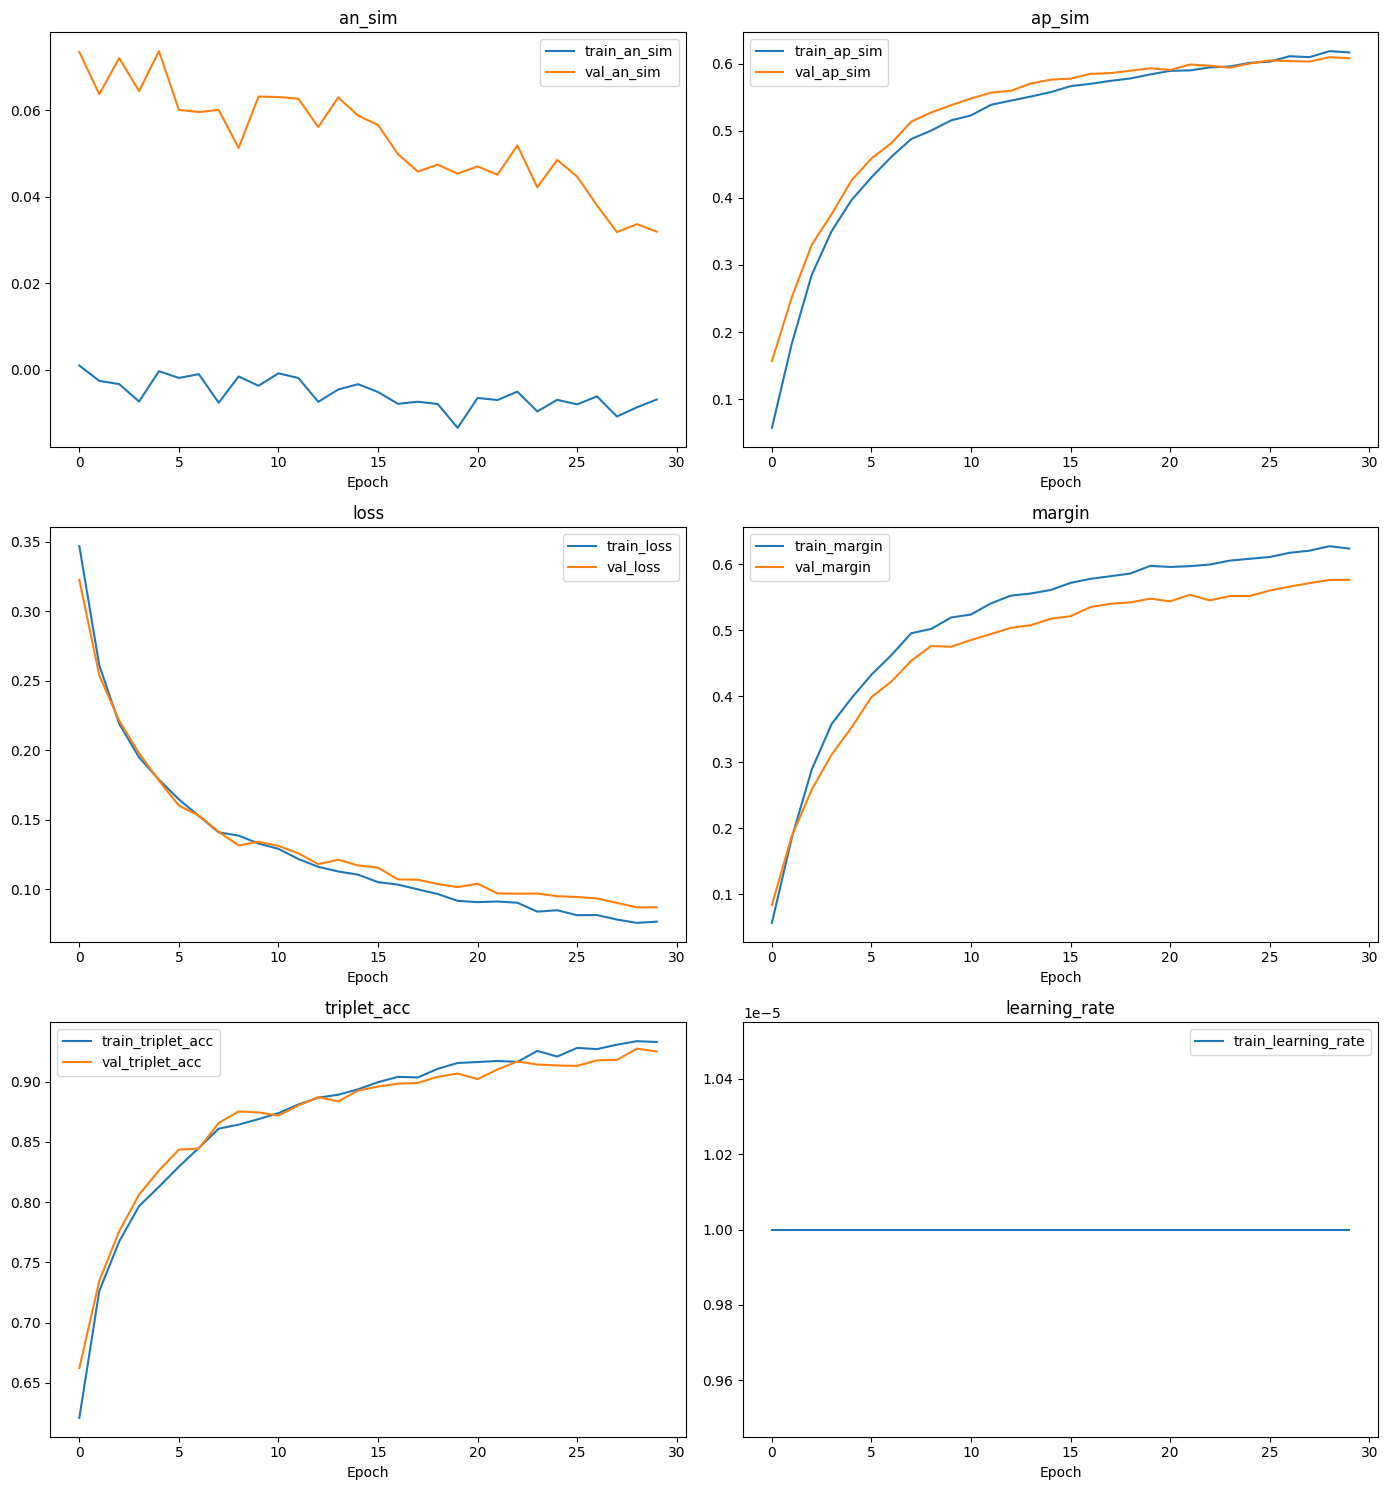

In [35]:
plot_keras_history(history)

In [36]:
os.makedirs("./models", exist_ok=True)
trainer.siamese_network.save(f"./models/mobilenet_siamese_model_40_{config.current_time}.keras")
trainer.embedding_model.save(f"./models/mobilenet_embedding_model_40_{config.current_time}.keras")

In [ ]:
trainer.siamese_network.load_weights("./models/mobilenet_siamese_model_40_20260320-070014.keras")

In [37]:
metrics_val = trainer.evaluate_dict(val_triplet)
metrics_val

786/786 ━━━━━━━━━━━━━━━━━━━━ 19s 24ms/step - an_sim: 0.0325 - ap_sim: 0.6107 - loss: 0.0877 - margin: 0.5782 - triplet_acc: 0.9233


{'an_sim': 0.03249029070138931,
 'ap_sim': 0.6106554865837097,
 'loss': 0.08774778991937637,
 'margin': 0.5781652331352234,
 'triplet_acc': 0.9233338832855225}

In [38]:
metrics_test = trainer.evaluate_dict(test_triplet)
metrics_test

434/434 ━━━━━━━━━━━━━━━━━━━━ 38s 50ms/step - an_sim: -0.0093 - ap_sim: 0.6340 - loss: 0.0692 - margin: 0.6433 - triplet_acc: 0.9435


{'an_sim': -0.009266280569136143,
 'ap_sim': 0.6340460181236267,
 'loss': 0.06917429715394974,
 'margin': 0.6433125734329224,
 'triplet_acc': 0.9434506893157959}

In [39]:
def build_author_confusion_matrix(
    df: pd.DataFrame,
    true_col: str = "author_i",
    pred_col: str = "author_j"
) -> pd.DataFrame:
    authors = sorted(df[true_col].unique())

    cm = confusion_matrix(
        df[true_col],
        df[pred_col],
        labels=authors
    )

    cm_df = pd.DataFrame(
        cm,
        index=authors,
        columns=authors
    )

    return cm_df

In [40]:
def display_heatmap(df: pd.DataFrame) -> None:
    plt.figure(figsize=(10, 8))
    sns.heatmap(df, cmap="Blues", linewidths=0.5)

    plt.xlabel("Predicted Author")
    plt.ylabel("True Author")
    plt.title("Confusion Matrix")
    plt.show()

In [41]:
triplet_evaluator = TripletEvaluator(
    model=trainer,
    logger=logger,
)

In [42]:
triplet_evaluator.data_generator = test_triplet
triplet_report = triplet_evaluator.evaluate()

13:01:38 - mobile_test_40_4 - INFO - === Triplet Evaluation Started ===
13:01:38 - mobile_test_40_4 - INFO - === Collecting triplet results ===
13:01:58 - mobile_test_40_4 - INFO - Total triplets collected: 1733
13:01:58 - mobile_test_40_4 - INFO - [LOCAL] acc=0.9429 gap=0.6387 error=0.0571 auc=0.9458
13:01:58 - mobile_test_40_4 - INFO - === Computing global metrics ===
13:01:58 - mobile_test_40_4 - INFO - === Global metrics computed ===
13:01:58 - mobile_test_40_4 - INFO - === Triplet Evaluation Finished ===


In [43]:
triplet_report.local_metrics.auc, triplet_report.local_metrics.triplet_accuracy

(0.9458357154439682, 0.9428736295441431)

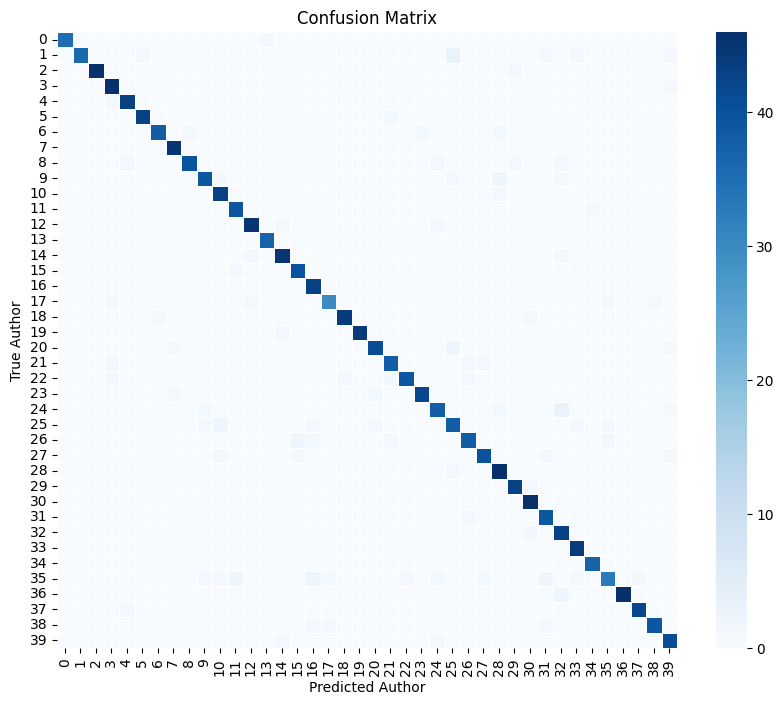

In [44]:
cm_df = build_author_confusion_matrix(
    triplet_report.df_triplets,
    true_col="anchor_label",
    pred_col="pred_label"
)
display_heatmap(cm_df)

In [45]:
triplet_report.global_metrics.df_by_score

,anchor_label,pred_label,accuracy,mean_gap,count,gap_norm,score
0,0,0,1.0,0.801902,35,0.934487,0.934487
1,1,1,1.0,0.627387,36,0.829051,0.829051
2,2,2,1.0,0.883106,46,0.983549,0.983549
3,3,3,1.0,0.723751,46,0.887270,0.887270
4,4,4,1.0,0.580120,43,0.800493,0.800493
5,5,5,1.0,0.760482,43,0.909463,0.909463
6,6,6,1.0,0.585773,38,0.803908,0.803908
7,7,7,1.0,0.872031,45,0.976858,0.976858
8,8,8,1.0,0.804570,40,0.936100,0.936100
9,9,9,1.0,0.550680,39,0.782706,0.782706


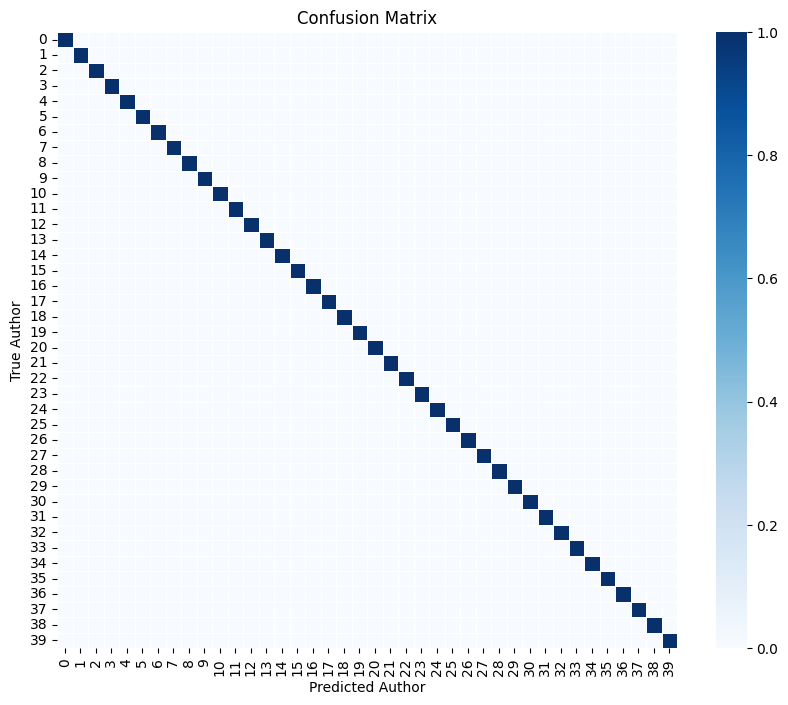

In [46]:
cm_df = build_author_confusion_matrix(
    triplet_report.global_metrics.df_by_score,
    true_col="anchor_label",
    pred_col="pred_label"
)
display_heatmap(cm_df)

In [47]:
train_gen = DataGenerator(
    split=train,
    batch_size=config.batch.train,
    seed=config.training.seed,
    augment=augment_train
)
val_gen = DataGenerator(
    split=val,
    batch_size=config.batch.validation,
    seed=config.training.seed,
    augment=augment
)
test_gen = DataGenerator(
    split=test,
    batch_size=config.batch.test,
    seed=config.training.seed,
    augment=augment
)

In [48]:
display_generator_info(train_gen)

13:02:38 - mobile_test_40_4 - INFO - Generator: DataGenerator
13:02:38 - mobile_test_40_4 - INFO - Number of samples: 18860
13:02:38 - mobile_test_40_4 - INFO - Batch size: 16
13:02:38 - mobile_test_40_4 - INFO - Steps per epoch: 1179
13:02:38 - mobile_test_40_4 - INFO - Shape: (180, 360)
13:02:38 - mobile_test_40_4 - INFO - Number of authors: 40


In [49]:
display_generator_info(val_gen)

13:02:39 - mobile_test_40_4 - INFO - Generator: DataGenerator
13:02:39 - mobile_test_40_4 - INFO - Number of samples: 6287
13:02:39 - mobile_test_40_4 - INFO - Batch size: 8
13:02:39 - mobile_test_40_4 - INFO - Steps per epoch: 786
13:02:39 - mobile_test_40_4 - INFO - Shape: (180, 360)
13:02:39 - mobile_test_40_4 - INFO - Number of authors: 40


In [50]:
display_generator_info(test_gen)

13:02:41 - mobile_test_40_4 - INFO - Generator: DataGenerator
13:02:41 - mobile_test_40_4 - INFO - Number of samples: 1733
13:02:41 - mobile_test_40_4 - INFO - Batch size: 4
13:02:41 - mobile_test_40_4 - INFO - Steps per epoch: 434
13:02:41 - mobile_test_40_4 - INFO - Shape: (180, 360)
13:02:41 - mobile_test_40_4 - INFO - Number of authors: 40


In [51]:
extractor = EmbeddingExtractor(
    model=trainer.embedding_model,
    logger=logger,
)

In [ ]:
strategy_pipeline = StrategyPipeline(
    strategies=[
        OneNNStrategy(), MeanStrategy(), CentroidStrategy(), TopKStrategy(k=5),
    ],
    aggregators=[PatchAggregator(), VoteAggregator(), ScoreAggregator()],
    logger=logger,
)

In [52]:
emb_evaluator = EmbeddingEvaluator(
    extractor=extractor,
    pipeline=strategy_pipeline,
    logger=logger,
    seed=config.training.seed
)

In [54]:
val_gen_results = emb_evaluator.evaluate(val_gen)

13:03:10 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Starting evaluation
13:03:10 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Preparing embeddings for distance computation
13:03:10 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Embeddings shape=(6287, 160)
13:03:10 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Building author pair similarities
13:03:12 - src.evaluator.embedding_evaluator - INFO - [Pairs] Built in 2.13s
13:03:12 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Running UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


13:03:43 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] UMAP completed in 31.09s
13:03:43 - src.evaluator.embedding_evaluator - INFO - [UMAP] Completed in 31.11s
13:03:43 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Computing intra/inter distances
13:03:43 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] intra=0.3985 | inter=0.9610 | ratio=0.4146 | time=0.04s
13:03:43 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Evaluating strategies: ['1nn', 'mean', 'centroid', 'topk']
13:03:43 - src.evaluator.embedding_strategies - INFO - [Pipeline] Applying strategy: 1nn
13:03:43 - src.evaluator.embedding_strategies - INFO - [Strategy:1NN] Computing similarity matrix
13:03:43 - src.evaluator.embedding_strategies - INFO - [Strategy:1NN] Accuracy=0.5911
13:03:43 - src.evaluator.embedding_evaluator - INFO - [Strategy: 1nn] patch_acc=0.5911 | vote_acc=1.0000 | score_acc=0.3250 | time=0.25s
13:03:43 - src.evaluator.embedding_st

In [55]:
logger.info(f"Intra distance: {val_gen_results.intra_distance}")
logger.info(f"Inter distance: {val_gen_results.inter_distance}")

for strategy_name, agg_results in val_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

13:04:06 - mobile_test_40_4 - INFO - Intra distance: 0.3984602454966351
13:04:06 - mobile_test_40_4 - INFO - Inter distance: 0.960963318888837
13:04:06 - mobile_test_40_4 - INFO - Strategy: 1nn
13:04:06 - mobile_test_40_4 - INFO - Patch accuracy: 0.5911
13:04:06 - mobile_test_40_4 - INFO - Vote accuracy:  1.0000
13:04:06 - mobile_test_40_4 - INFO - Score accuracy: 0.3250
13:04:06 - mobile_test_40_4 - INFO - ----------------------------------------
13:04:06 - mobile_test_40_4 - INFO - Strategy: mean
13:04:06 - mobile_test_40_4 - INFO - Patch accuracy: 0.5484
13:04:06 - mobile_test_40_4 - INFO - Vote accuracy:  0.8000
13:04:06 - mobile_test_40_4 - INFO - Score accuracy: 0.2750
13:04:06 - mobile_test_40_4 - INFO - ----------------------------------------
13:04:06 - mobile_test_40_4 - INFO - Strategy: centroid
13:04:06 - mobile_test_40_4 - INFO - Patch accuracy: 0.6059
13:04:06 - mobile_test_40_4 - INFO - Vote accuracy:  1.0000
13:04:06 - mobile_test_40_4 - INFO - Score accuracy: 0.2250
13

In [57]:
test_gen_results = emb_evaluator.evaluate(test_gen)

13:04:20 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Starting evaluation
13:04:20 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Preparing embeddings for distance computation
13:04:20 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Embeddings shape=(1733, 160)
13:04:20 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Building author pair similarities
13:04:20 - src.evaluator.embedding_evaluator - INFO - [Pairs] Built in 0.14s
13:04:20 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Running UMAP...


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


13:04:28 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] UMAP completed in 8.39s
13:04:28 - src.evaluator.embedding_evaluator - INFO - [UMAP] Completed in 8.40s
13:04:28 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Computing intra/inter distances
13:04:28 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] intra=0.3727 | inter=1.0032 | ratio=0.3715 | time=0.03s
13:04:28 - src.evaluator.embedding_evaluator - INFO - [EmbeddingEvaluator] Evaluating strategies: ['1nn', 'mean', 'centroid', 'topk']
13:04:28 - src.evaluator.embedding_strategies - INFO - [Pipeline] Applying strategy: 1nn
13:04:28 - src.evaluator.embedding_strategies - INFO - [Strategy:1NN] Computing similarity matrix
13:04:28 - src.evaluator.embedding_strategies - INFO - [Strategy:1NN] Accuracy=0.8021
13:04:28 - src.evaluator.embedding_evaluator - INFO - [Strategy: 1nn] patch_acc=0.8021 | vote_acc=1.0000 | score_acc=0.4250 | time=0.04s
13:04:28 - src.evaluator.embedding_stra

In [58]:
logger.info(f"Intra distance: {test_gen_results.intra_distance}")
logger.info(f"Inter distance: {test_gen_results.inter_distance}")

for strategy_name, agg_results in test_gen_results.strategy_results.items():

    logger.info(f"Strategy: {strategy_name}")

    for agg_name, result in agg_results.items():
        acc = result.metrics.get("accuracy", np.nan)
        logger.info(f"{agg_name.capitalize()} accuracy: {acc:.4f}")

    logger.info(f"{'-'*40}")

13:04:44 - mobile_test_40_4 - INFO - Intra distance: 0.3726808633342552
13:04:44 - mobile_test_40_4 - INFO - Inter distance: 1.00316379835352
13:04:44 - mobile_test_40_4 - INFO - Strategy: 1nn
13:04:44 - mobile_test_40_4 - INFO - Patch accuracy: 0.8021
13:04:44 - mobile_test_40_4 - INFO - Vote accuracy:  1.0000
13:04:44 - mobile_test_40_4 - INFO - Score accuracy: 0.4250
13:04:44 - mobile_test_40_4 - INFO - ----------------------------------------
13:04:44 - mobile_test_40_4 - INFO - Strategy: mean
13:04:44 - mobile_test_40_4 - INFO - Patch accuracy: 0.6088
13:04:44 - mobile_test_40_4 - INFO - Vote accuracy:  0.8250
13:04:44 - mobile_test_40_4 - INFO - Score accuracy: 0.3750
13:04:44 - mobile_test_40_4 - INFO - ----------------------------------------
13:04:44 - mobile_test_40_4 - INFO - Strategy: centroid
13:04:44 - mobile_test_40_4 - INFO - Patch accuracy: 0.6728
13:04:44 - mobile_test_40_4 - INFO - Vote accuracy:  1.0000
13:04:44 - mobile_test_40_4 - INFO - Score accuracy: 0.4000
13:

In [59]:
viz = EmbeddingVisualizer(
    report=test_gen_results,
    logger=logger,
    loader=test.loader,
)

In [ ]:
viz.set_strategy("1nn")

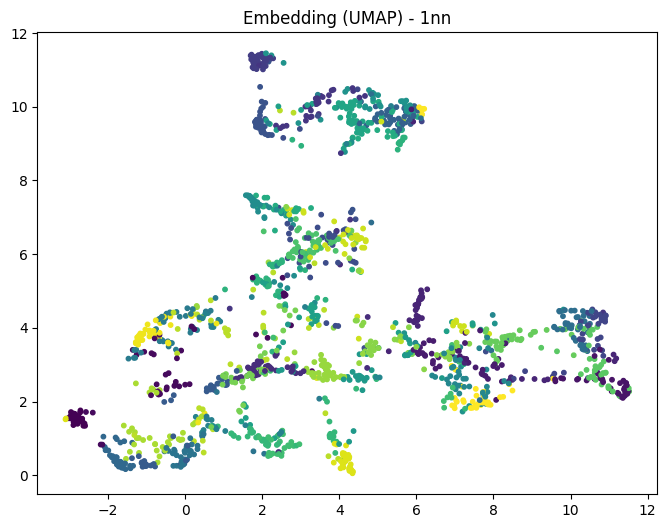

In [60]:
viz.plot_embeddings_2d()

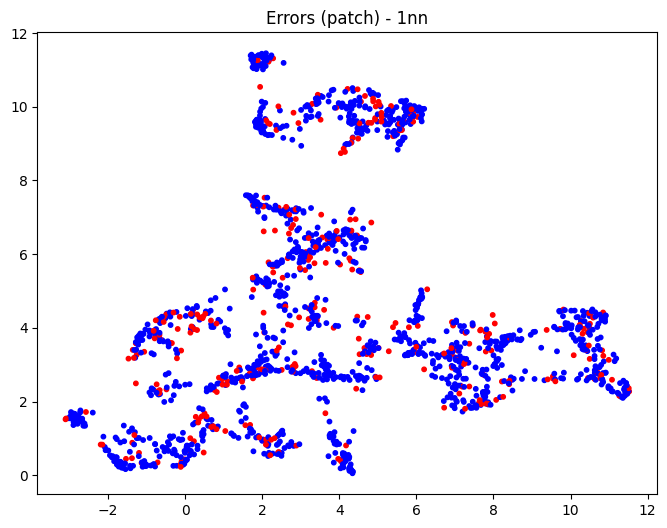

In [61]:
viz.plot_errors_2d(level="patch")

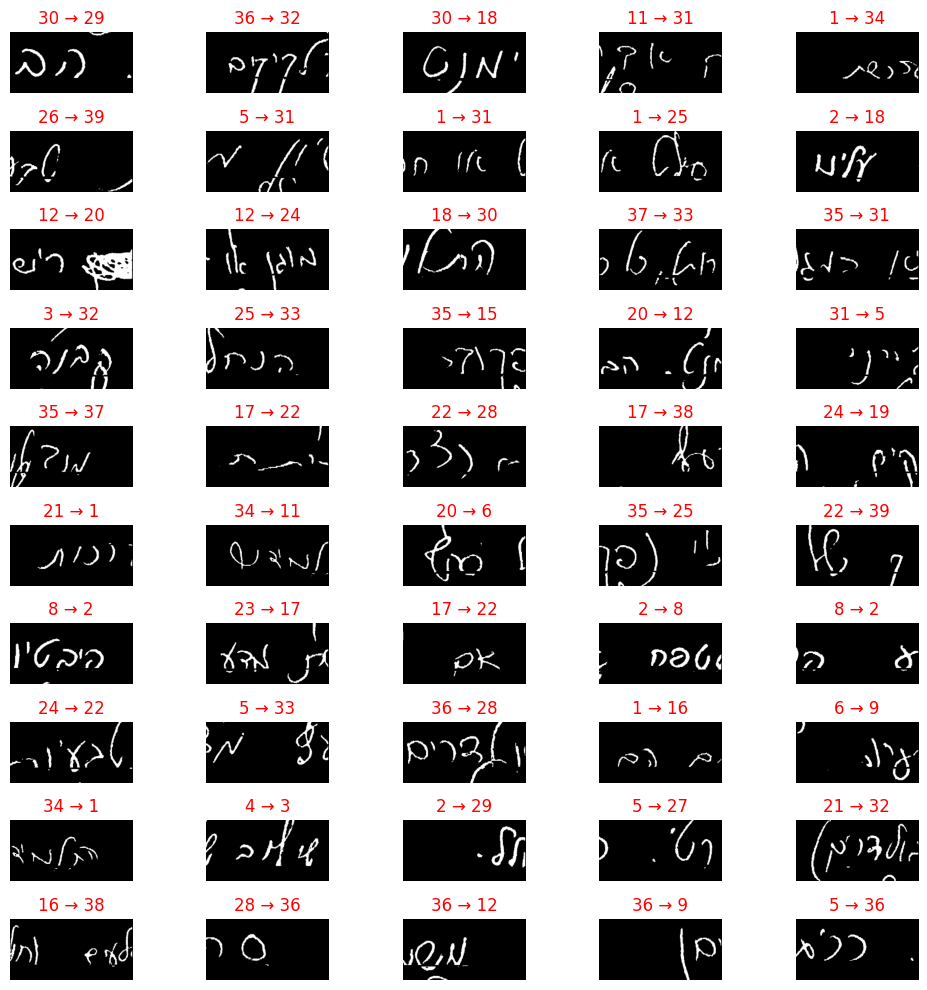

In [62]:
viz.plot_error_images()

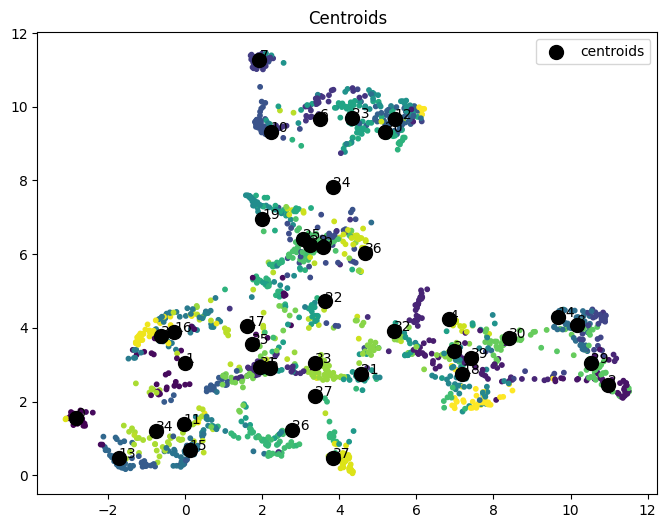

In [63]:
viz.plot_centroids()

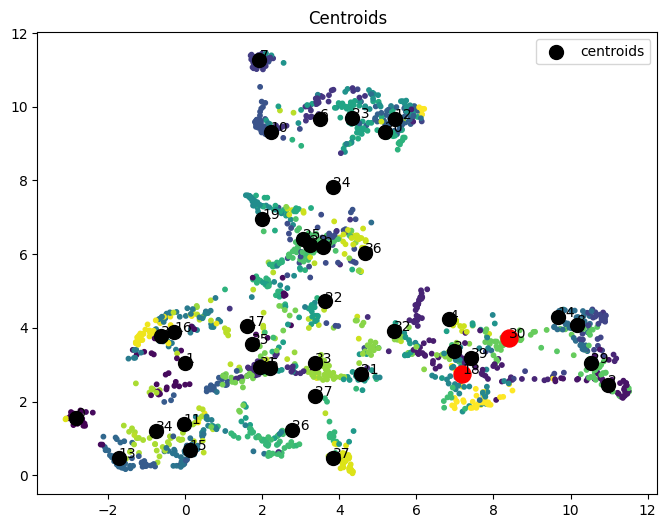

In [64]:
viz.plot_centroids([18, 30])

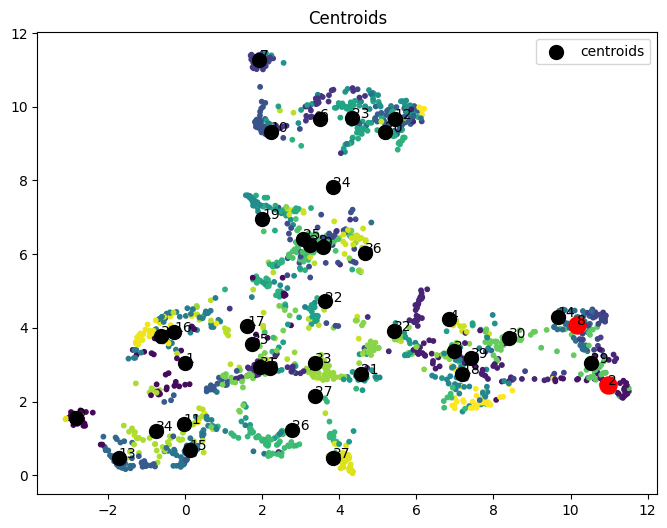

In [65]:
viz.plot_centroids([2, 8])

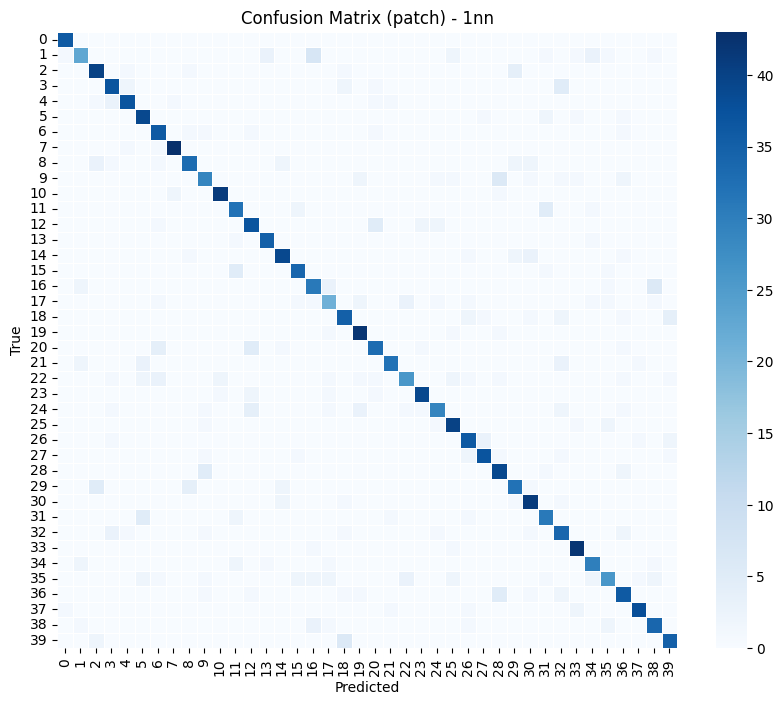

In [67]:
viz.plot_confusion(level="patch")

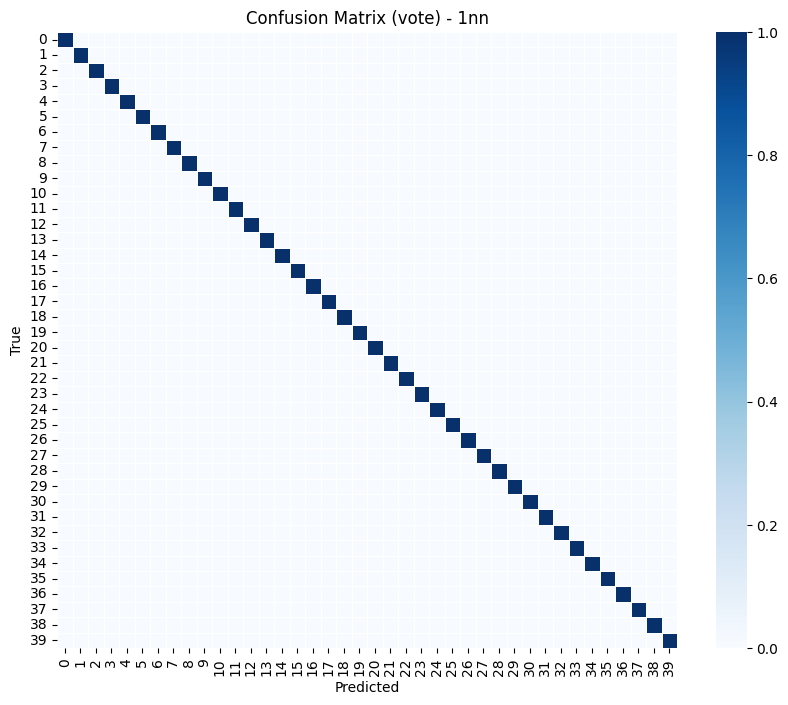

In [66]:
viz.plot_confusion(level="vote")

In [ ]:
viz.set_strategy("topk")

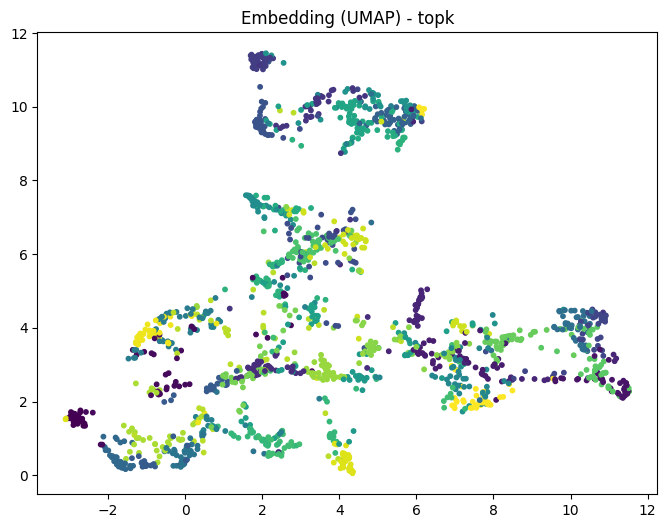

In [70]:
viz.plot_embeddings_2d()

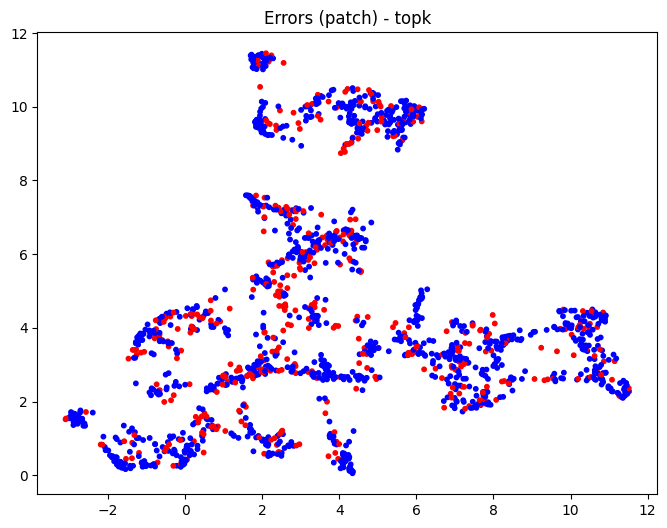

In [71]:
viz.plot_errors_2d(level="patch")

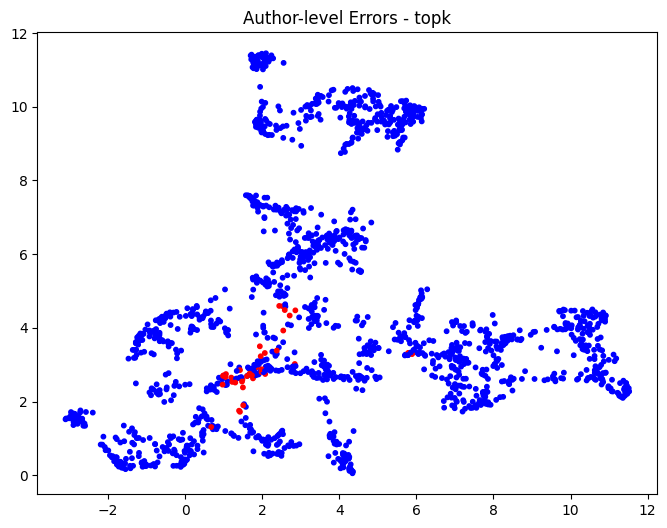

In [72]:
viz.plot_author_errors_2d()

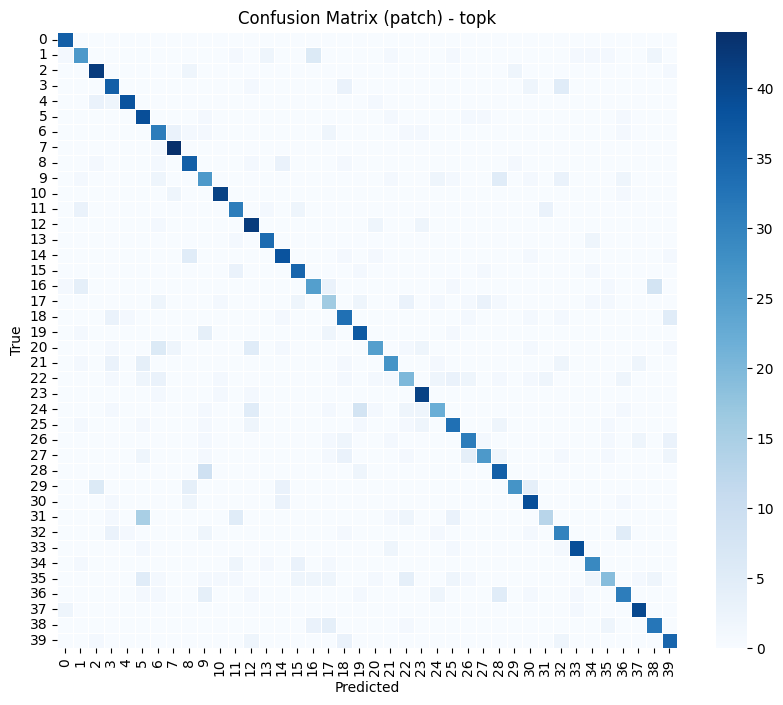

In [76]:
viz.plot_confusion("patch")

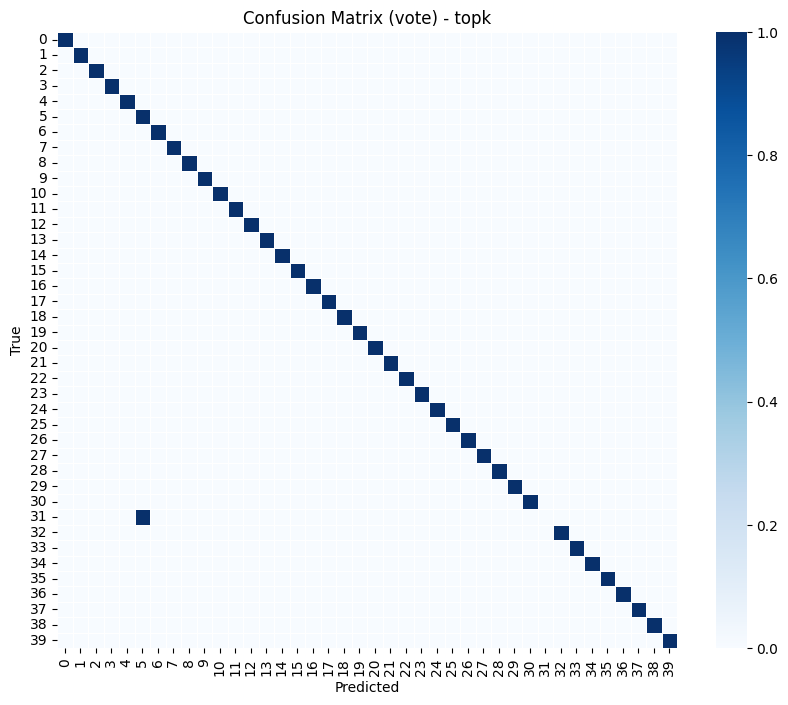

In [73]:
viz.plot_confusion("vote")

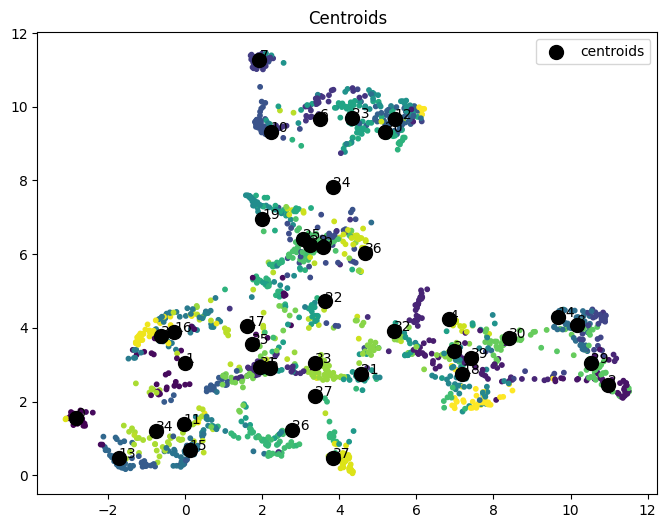

In [74]:
viz.plot_centroids()

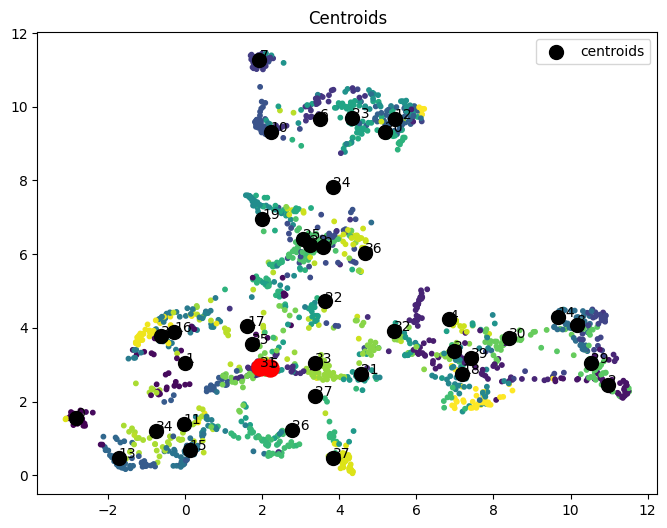

In [75]:
viz.plot_centroids([5, 31])